# 📊 Análise de Agrupamento com PCA e K-Means
## Dataset: Bank Marketing — UCI Repository

**Objetivo:** Explorar a estrutura latente dos dados de marketing bancário usando duas técnicas fundamentais de Machine Learning não supervisionado:

| Técnica | Papel neste notebook |
|---|---|
| **PCA** (*Principal Component Analysis*) | Redução de dimensionalidade + Visualização |
| **K-Means** | Agrupamento de clientes (Clusterização) |

> 💡 Este notebook é um instrumento **didático**. Cada seção apresenta a **teoria** antes da implementação prática.

---

**Dataset:** 41.188 registros · 20 variáveis · Target binário `y` *(o cliente assinou um depósito a prazo?)*

In [1]:
# Execute esta célula se estiver no Google Colab.
# Em ambiente local com o arquivo já disponível, pode pular.
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files
    print("Colab detectado. Faca upload de 'bank-additional-full.csv'")
    uploaded = files.upload()
    FILEPATH = list(uploaded.keys())[0]
else:
    FILEPATH = 'bank-additional-full.csv'
    print(f"Ambiente local. Usando: {FILEPATH}")

Ambiente local. Usando: bank-additional-full.csv


In [2]:
# ─── Importações ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# ─── Configurações visuais ─────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
sns.set_palette('tab10')

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


---
# 1. 📐 Teoria: PCA — Análise de Componentes Principais

## O problema da dimensionalidade

Nosso dataset tem **9 variáveis numéricas**. Visualizar ou comparar dados em 9 dimensões é impossível para o cérebro humano. O PCA resolve isso criando "super-variáveis" que resumem a informação original.

> 🎯 **Analogia:** Imagine fotografar um objeto 3D. A foto é 2D, mas ainda captura a maior parte da forma do objeto — ela é a *projeção mais informativa*. O PCA faz exatamente isso: projeta os dados em dimensões menores **preservando o máximo de informação**.

---

## Como o PCA funciona?

O PCA busca **direções de máxima variância** nos dados:

1. **PC1 — 1ª Componente Principal:** A direção onde os dados "se espalham mais" (maior variância)
2. **PC2 — 2ª Componente Principal:** Perpendicular à PC1, com a segunda maior variância
3. **PC3, PC4, ...:** Sequência de direções ortogonais, em ordem decrescente de variância

Matematicamente, isso é feito pela **decomposição espectral da matriz de covariância** (autovalores e autovetores). O que importa: **cada CP é uma combinação linear das variáveis originais**.

---

## Variância Explicada

Cada componente "captura" uma fração da variância total:

- O **Scree Plot** mostra quanto cada CP explica individualmente
- A **Curva de Variância Acumulada** indica quantas CPs são suficientes (critério usual: 80–90% acumulado)

---

## Loadings — os "pesos" das variáveis

Os **loadings** indicam o quanto cada variável original contribui para cada CP:
- Loading alto positivo → variável empurra os dados naquela direção
- Loading alto negativo → variável empurra no sentido oposto
- Loading próximo de zero → variável pouco influente naquela componente

O **Biplot** combina a projeção dos dados (pontos) e os loadings (setas) em um único gráfico.

---

> ⚠️ **Limitação importante:** Após o PCA, as componentes são abstrações matemáticas — perdemos a interpretabilidade direta. PC1 não é mais "idade" ou "taxa de juros"; é uma combinação de várias variáveis.

---
# 2. 🔵 Teoria: K-Means — Agrupamento por Centróides

## ⚠️ Primeiro: KNN ≠ K-Means (distinção importante!)

Dois algoritmos com nomes parecidos, propósitos completamente diferentes:

| Característica | **KNN** (K-Nearest Neighbors) | **K-Means** |
|---|---|---|
| **Tipo** | Supervisionado | Não supervisionado |
| **Tarefa** | Classificação / Regressão | Agrupamento (Clustering) |
| **Usa labels?** | ✅ Sim | ❌ Não |
| **"K" significa** | Nº de vizinhos mais próximos | Nº de clusters (grupos) |
| **Quando usar** | Tenho exemplos rotulados | Quero descobrir grupos naturais |

> ✏️ Neste notebook usamos **K-Means**, pois queremos descobrir **grupos naturais** nos clientes *sem* usar o target `y`. Isso é aprendizado **não supervisionado**.

---

## O que é K-Means?

O K-Means divide os dados em **K grupos**, onde cada observação pertence ao grupo cujo **centróide** (ponto médio) é o mais próximo.

> 🎯 **Analogia:** Imagine instalar K academias numa cidade para minimizar a distância média que cada morador percorre. O K-Means encontra as **melhores localizações** para esses K centros de gravidade.

---

## Algoritmo (passo a passo)

```
1. INICIALIZAÇÃO:  Escolhe K pontos aleatórios como centróides iniciais
2. ATRIBUIÇÃO:     Cada ponto vai ao centróide mais próximo (distância euclidiana)
3. ATUALIZAÇÃO:    Recalcula cada centróide como a média dos pontos do grupo
4. REPETE:         Passos 2-3 até convergência (centróides estabilizam)
```

---

## Como escolher K?

### 📐 Método do Cotovelo (Elbow Method)
Plota a **inércia** (soma das distâncias² dos pontos ao seu centróide) para cada K. O "cotovelo" da curva indica onde o ganho marginal diminui — esse é o K ótimo.

### 📊 Silhouette Score
Mede a qualidade da separação: varia de **-1 a +1**; quanto mais próximo de 1, melhor os clusters estão separados e coesos internamente.

---

> ⚠️ O K-Means usa **distância euclidiana**. Uma variável em escala de milhares dominaria completamente o cálculo em relação a uma que varia entre 0 e 1.
> **Padronização com `StandardScaler` é obrigatória antes de aplicar K-Means.**

---
# 3. 🗂️ Preparação dos Dados

Antes de aplicar qualquer técnica:
1. Carregar e inspecionar o dataset
2. Identificar e excluir `duration` (data leakage)
3. Selecionar as variáveis numéricas adequadas
4. Padronizar com `StandardScaler`

In [3]:
# ─── Carga do Dataset ─────────────────────────────────────────────────────────
# Atenção: o arquivo usa ponto-e-vírgula (;) como separador!

try:
    df = pd.read_csv(FILEPATH, sep=';')
except NameError:
    df = pd.read_csv('bank-additional-full.csv', sep=';')

print(f"✅ Dataset carregado com sucesso!")
print(f"   Shape      : {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"   Ausentes   : {df.isnull().sum().sum()}")
print()
print("Tipos das variáveis:")
for col, dtype in df.dtypes.items():
    print(f"  {col:<22} {str(dtype)}")

df.head(3)

✅ Dataset carregado com sucesso!
   Shape      : 41,188 linhas × 21 colunas
   Ausentes   : 0

Tipos das variáveis:
  age                    int64
  job                    object
  marital                object
  education              object
  default                object
  housing                object
  loan                   object
  contact                object
  month                  object
  day_of_week            object
  duration               int64
  campaign               int64
  pdays                  int64
  previous               int64
  poutcome               object
  emp.var.rate           float64
  cons.price.idx         float64
  cons.conf.idx          float64
  euribor3m              float64
  nr.employed            float64
  y                      object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# ─── ⚠️ ALERTA: Data Leakage — variável 'duration' ───────────────────────────
sep_line = "=" * 65
print(sep_line)
print("  ⚠️  ALERTA DE DATA LEAKAGE: variável 'duration'")
print(sep_line)
print("  A variável 'duration' = duração da última ligação (em segundos).")
print()
print("  PROBLEMA: ela só é conhecida APÓS a ligação terminar.")
print("    → Ligação curta:  duration baixo → provavelmente não converteu")
print("    → Ligação longa:  duration alto  → provavelmente converteu")
print()
print("  Incluir 'duration' em modelos preditivos causa VAZAMENTO DE DADOS:")
print("  o modelo aprende algo que NÃO estaria disponível no momento da decisão")
print("  (i.e., antes de ligar para o cliente).")
print()
print("  DECISÃO: variável excluída de toda a análise.")
print(sep_line)
print()

# ─── Seleção de features numéricas ────────────────────────────────────────────
numeric_features = [
    'age',             # Idade do cliente
    'campaign',        # Número de contatos nesta campanha
    'pdays',           # Dias desde o último contato (999 = nunca contatado)
    'previous',        # Contatos em campanhas anteriores
    'emp.var.rate',    # Taxa de variação do emprego (trimestral)
    'cons.price.idx',  # Índice de preços ao consumidor (mensal)
    'cons.conf.idx',   # Índice de confiança do consumidor (mensal)
    'euribor3m',       # Taxa Euribor 3 meses (diária)
    'nr.employed'      # Número de funcionários (trimestral)
]

print(f"✅ Features selecionadas ({len(numeric_features)}):")
for f in numeric_features:
    print(f"   • {f}")

X = df[numeric_features].copy()
print(f"\n   Shape da matriz X: {X.shape}")

  ⚠️  ALERTA DE DATA LEAKAGE: variável 'duration'
  A variável 'duration' = duração da última ligação (em segundos).

  PROBLEMA: ela só é conhecida APÓS a ligação terminar.
    → Ligação curta:  duration baixo → provavelmente não converteu
    → Ligação longa:  duration alto  → provavelmente converteu

  Incluir 'duration' em modelos preditivos causa VAZAMENTO DE DADOS:
  o modelo aprende algo que NÃO estaria disponível no momento da decisão
  (i.e., antes de ligar para o cliente).

  DECISÃO: variável excluída de toda a análise.

✅ Features selecionadas (9):
   • age
   • campaign
   • pdays
   • previous
   • emp.var.rate
   • cons.price.idx
   • cons.conf.idx
   • euribor3m
   • nr.employed

   Shape da matriz X: (41188, 9)


In [5]:
# ─── Codificar o target y ─────────────────────────────────────────────────────
le = LabelEncoder()
df['y_encoded'] = le.fit_transform(df['y'])   # no → 0,  yes → 1
y = df['y_encoded'].values

print("Distribuição do target y:")
for val, cnt in df['y'].value_counts().items():
    bar = '█' * int(cnt / 800)
    print(f"  {val:>4}: {cnt:>6,}  ({cnt/len(df)*100:.1f}%)  {bar}")

# ─── Padronização ──────────────────────────────────────────────────────────────
print("\n📊 Estatísticas ANTES da padronização:")
display(X.describe().round(2))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Dados padronizados (média ≈ 0, desvio padrão ≈ 1)")
print("   Por quê? PCA e K-Means são sensíveis à escala das variáveis.")
print(f"   Shape da matriz padronizada: {X_scaled.shape}")

Distribuição do target y:
    no: 36,548  (88.7%)  █████████████████████████████████████████████
   yes:  4,640  (11.3%)  █████

📊 Estatísticas ANTES da padronização:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10



✅ Dados padronizados (média ≈ 0, desvio padrão ≈ 1)
   Por quê? PCA e K-Means são sensíveis à escala das variáveis.
   Shape da matriz padronizada: (41188, 9)


---
# 4. 🔬 Aplicação do PCA

Etapas desta seção:
1. Ajustar PCA com **todas** as componentes → verificar variância explicada
2. **Scree Plot** + **Curva de Variância Acumulada** → decidir quantas CPs usar
3. Projetar em 2D → criar o **Biplot** (pontos + setas das variáveis originais, coloridos por `y`)
4. Analisar a **tabela de loadings**

In [6]:
# ─── PCA com todas as componentes ─────────────────────────────────────────────
pca_full  = PCA()
pca_full.fit(X_scaled)

var_ratio  = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(var_ratio)
n_features = len(numeric_features)

print("Variância explicada por Componente Principal:")
print(f"{'CP':<6} {'Eigenvalue':>12} {'% Var':>8} {'% Acum':>8}  Barra")
print("-" * 60)
for i, (ev, v, cv) in enumerate(zip(pca_full.explained_variance_, var_ratio, cum_var), 1):
    bar = chr(9608) * int(v * 45)
    print(f"PC{i:<4} {ev:>12.4f}  {v*100:>6.1f}%  {cv*100:>6.1f}%  {bar}")

n_comp_85 = int(np.argmax(cum_var >= 0.85) + 1)
n_comp_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"\n📌 Componentes para ≥ 85% de variância: PC1 a PC{n_comp_85}")
print(f"   Componentes para ≥ 90% de variância: PC1 a PC{n_comp_90}")

Variância explicada por Componente Principal:
CP       Eigenvalue    % Var   % Acum  Barra
------------------------------------------------------------
PC1          3.8937    43.3%    43.3%  ███████████████████
PC2          1.3566    15.1%    58.3%  ██████
PC3          1.0776    12.0%    70.3%  █████
PC4          0.9757    10.8%    81.1%  ████
PC5          0.8487     9.4%    90.6%  ████
PC6          0.4259     4.7%    95.3%  ██
PC7          0.3865     4.3%    99.6%  █
PC8          0.0249     0.3%    99.9%  
PC9          0.0106     0.1%   100.0%  

📌 Componentes para ≥ 85% de variância: PC1 a PC5
   Componentes para ≥ 90% de variância: PC1 a PC5


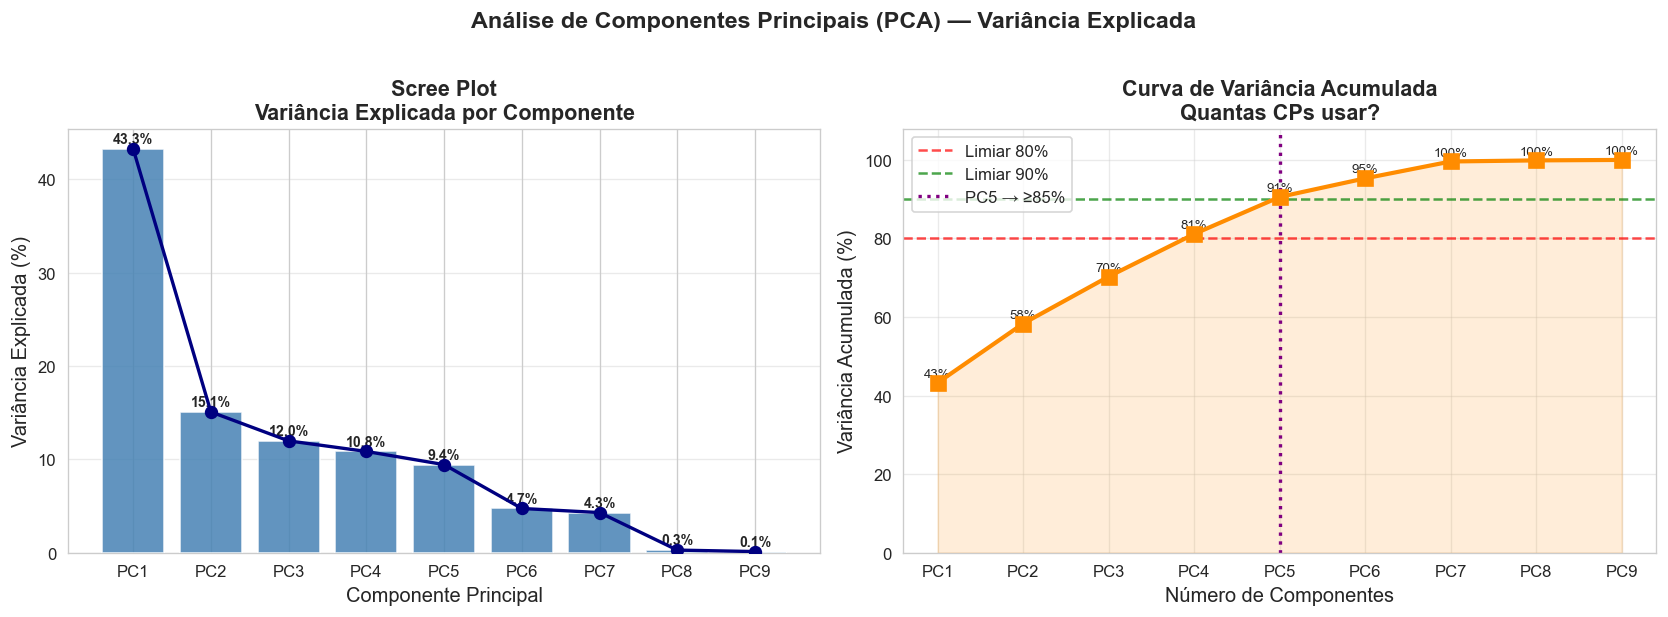


💡 Com 5 componentes, capturamos ≥ 85% da variância original.
   Usaremos PC1 e PC2 (2D) para o Biplot e visualização dos clusters.


In [7]:
# ─── Scree Plot + Curva de Variância Acumulada ────────────────────────────────
x_ticks = list(range(1, n_features + 1))
labels  = [f'PC{i}' for i in x_ticks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scree Plot ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(x_ticks, var_ratio * 100,
               color='steelblue', alpha=0.85, edgecolor='white', zorder=3)
ax1.plot(x_ticks, var_ratio * 100, 'o-', color='navy', lw=2, markersize=7, zorder=4)
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Variância Explicada (%)', fontsize=12)
ax1.set_title('Scree Plot\nVariância Explicada por Componente', fontsize=13, fontweight='bold')
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(labels)
for bar, v in zip(bars, var_ratio):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax1.grid(axis='y', alpha=0.4)

# ── Curva de Variância Acumulada ──────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x_ticks, cum_var * 100, 's-', color='darkorange', lw=2.5, markersize=9, zorder=4)
ax2.fill_between(x_ticks, cum_var * 100, alpha=0.15, color='darkorange')

for thresh, color, lbl in [(80, 'red', '80%'), (90, 'green', '90%')]:
    ax2.axhline(thresh, color=color, linestyle='--', alpha=0.7, lw=1.5, label=f'Limiar {lbl}')

ax2.axvline(n_comp_85, color='purple', linestyle=':', lw=2, label=f'PC{n_comp_85} → ≥85%')

for xi, cv in zip(x_ticks, cum_var):
    ax2.text(xi, cv * 100 + 1.5, f'{cv*100:.0f}%', ha='center', fontsize=8)

ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Variância Acumulada (%)', fontsize=12)
ax2.set_title('Curva de Variância Acumulada\nQuantas CPs usar?', fontsize=13, fontweight='bold')
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(labels)
ax2.set_ylim([0, 108])
ax2.legend(fontsize=10)
ax2.grid(alpha=0.4)

plt.suptitle('Análise de Componentes Principais (PCA) — Variância Explicada',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n💡 Com {n_comp_85} componentes, capturamos ≥ 85% da variância original.")
print(f"   Usaremos PC1 e PC2 (2D) para o Biplot e visualização dos clusters.")

PC1: 43.3%  |  PC2: 15.1%  |  Total 2D: 58.3%


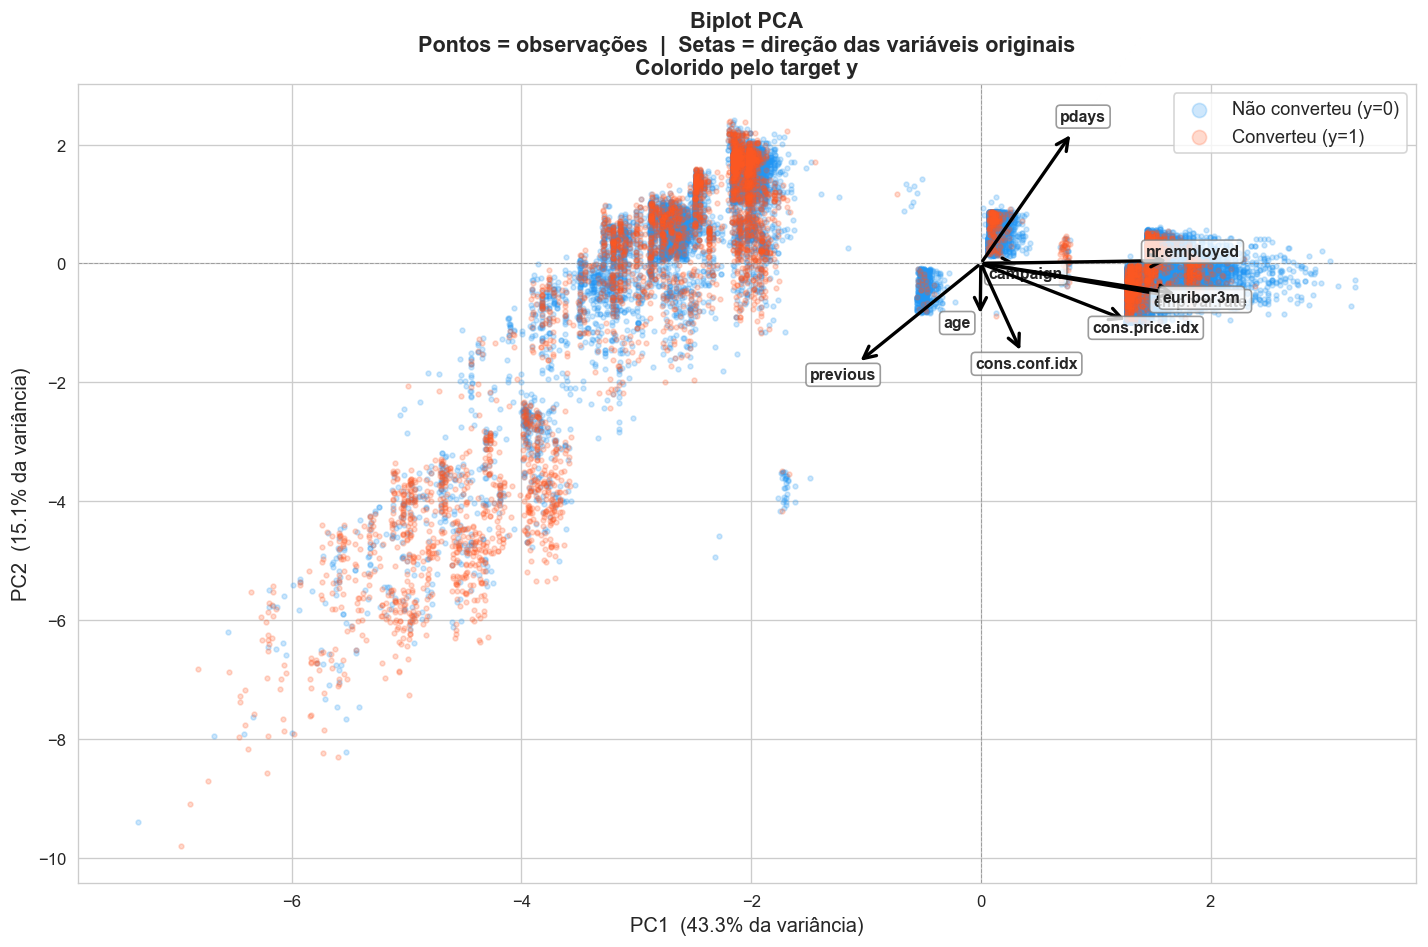

In [8]:
# ─── PCA 2D — Projeção para Visualização ──────────────────────────────────────
pca_2d = PCA(n_components=2)
X_pca  = pca_2d.fit_transform(X_scaled)

pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100
print(f"PC1: {pc1_var:.1f}%  |  PC2: {pc2_var:.1f}%  |  Total 2D: {pc1_var + pc2_var:.1f}%")

# ─── BIPLOT ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter colorido por y (target real)
colors_y = {0: '#2196F3', 1: '#FF5722'}
labels_y = {0: 'Não converteu (y=0)', 1: 'Converteu (y=1)'}
for lbl in [0, 1]:
    mask = y == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors_y[lbl], label=labels_y[lbl],
               alpha=0.22, s=8, rasterized=True)

# Setas dos loadings (biplot)
loadings = pca_2d.components_.T   # shape: (n_features, 2)
scale    = 3.5

for i, var in enumerate(numeric_features):
    lx = loadings[i, 0] * scale
    ly = loadings[i, 1] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.0, mutation_scale=18))
    # Deslocar label da ponta da seta
    tx = lx * 1.12 if abs(lx) > 0.2 else lx + 0.2 * (1 if lx >= 0 else -1)
    ty = ly * 1.12 if abs(ly) > 0.2 else ly + 0.15 * (1 if ly >= 0 else -1)
    ax.text(tx, ty, var, fontsize=9.5, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.78, edgecolor='gray'))

ax.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.6)
ax.axvline(0, color='gray', lw=0.6, ls='--', alpha=0.6)
ax.set_xlabel(f'PC1  ({pc1_var:.1f}% da variância)', fontsize=12)
ax.set_ylabel(f'PC2  ({pc2_var:.1f}% da variância)', fontsize=12)
ax.set_title('Biplot PCA\nPontos = observações  |  Setas = direção das variáveis originais\nColorido pelo target y',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right', markerscale=3)

plt.tight_layout()
plt.savefig('fig_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ─── Tabela de Loadings ───────────────────────────────────────────────────────
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=numeric_features,
    columns=['PC1', 'PC2']
).round(4)

loadings_df['|PC1|'] = loadings_df['PC1'].abs()
loadings_df['|PC2|'] = loadings_df['PC2'].abs()
loadings_df = loadings_df.sort_values('|PC1|', ascending=False)

print("📋 Tabela de Loadings — Contribuição de Cada Variável às Componentes Principais")
print("   (valores mais afastados de 0 indicam maior contribuição)")
print()

styled = (loadings_df[['PC1', 'PC2']]
          .style
          .background_gradient(subset=['PC1'], cmap='RdBu_r', vmin=-1, vmax=1)
          .background_gradient(subset=['PC2'], cmap='RdBu_r', vmin=-1, vmax=1)
          .format('{:.4f}')
          .set_caption('Loadings PCA — Ordenados por |PC1|'))
display(styled)

top_pc1 = loadings_df['|PC1|'].idxmax()
top_pc2 = loadings_df['|PC2|'].idxmax()
print(f"\n💡 Maior contribuição para PC1: '{top_pc1}' (loading = {loadings_df.loc[top_pc1, 'PC1']:.4f})")
print(f"   Maior contribuição para PC2: '{top_pc2}' (loading = {loadings_df.loc[top_pc2, 'PC2']:.4f})")

📋 Tabela de Loadings — Contribuição de Cada Variável às Componentes Principais
   (valores mais afastados de 0 indicam maior contribuição)



,PC1,PC2
euribor3m,0.4906,-0.1470
emp.var.rate,0.4882,-0.1615
nr.employed,0.4702,0.0143
cons.price.idx,0.3665,-0.2762
previous,-0.3059,-0.4778
pdays,0.2273,0.6300
cons.conf.idx,0.1016,-0.4306
campaign,0.1000,-0.0050
age,-0.0016,-0.2553



💡 Maior contribuição para PC1: 'euribor3m' (loading = 0.4906)
   Maior contribuição para PC2: 'pdays' (loading = 0.6300)


---
# 5. 🔵 Aplicação do K-Means

Com os dados padronizados, três etapas:

1. **Escolha de K:** Método do Cotovelo + Silhouette Score
2. **Ajuste final:** K-Means com o K escolhido
3. **Visualização lado a lado:** Clusters no espaço PCA · Target real `y` no espaço PCA

Calculando inércia para K = 2 a 10...
  K= 2  inércia = 225,757.2
  K= 3  inércia = 175,103.9
  K= 4  inércia = 153,207.7
  K= 5  inércia = 138,143.4
  K= 6  inércia = 117,601.7
  K= 7  inércia = 109,417.0
  K= 8  inércia = 99,353.6
  K= 9  inércia = 94,026.4
  K=10  inércia = 86,107.9


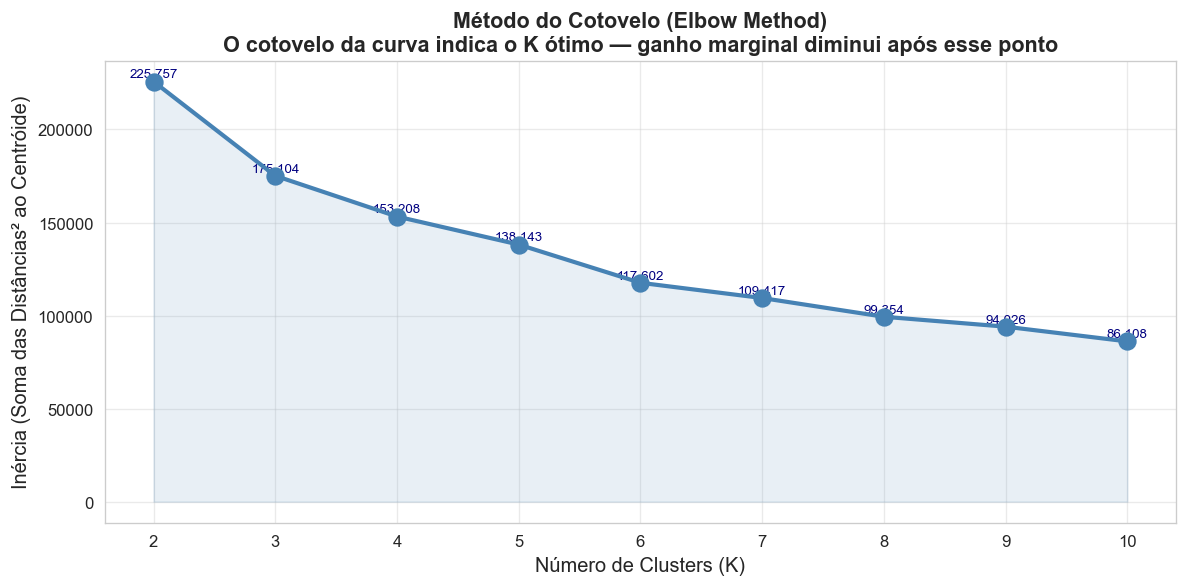


💡 Observe onde a curva começa a 'dobrar' — esse é o K do cotovelo.


In [10]:
# ─── Método do Cotovelo (Elbow Method) ────────────────────────────────────────
K_range  = range(2, 11)
inertias = []

print("Calculando inércia para K = 2 a 10...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k:2d}  inércia = {km.inertia_:,.1f}")

# ── Gráfico ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'o-', color='steelblue', lw=2.5, markersize=10, zorder=4)
ax.fill_between(K_range, inertias, alpha=0.12, color='steelblue')

for k, inertia in zip(K_range, inertias):
    ax.text(k, inertia + max(inertias) * 0.012, f'{inertia:,.0f}',
            ha='center', fontsize=8, color='navy')

ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Inércia (Soma das Distâncias² ao Centróide)', fontsize=12)
ax.set_title('Método do Cotovelo (Elbow Method)\n'
             'O cotovelo da curva indica o K ótimo — ganho marginal diminui após esse ponto',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(K_range))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Observe onde a curva começa a 'dobrar' — esse é o K do cotovelo.")

Calculando Silhouette Score para K = 2 a 10 (sample_size=5000)...

  K= 2  Silhouette = 0.4731
  K= 3  Silhouette = 0.4880
  K= 4  Silhouette = 0.4673
  K= 5  Silhouette = 0.2914
  K= 6  Silhouette = 0.3045
  K= 7  Silhouette = 0.3116
  K= 8  Silhouette = 0.3410
  K= 9  Silhouette = 0.3341
  K=10  Silhouette = 0.3315


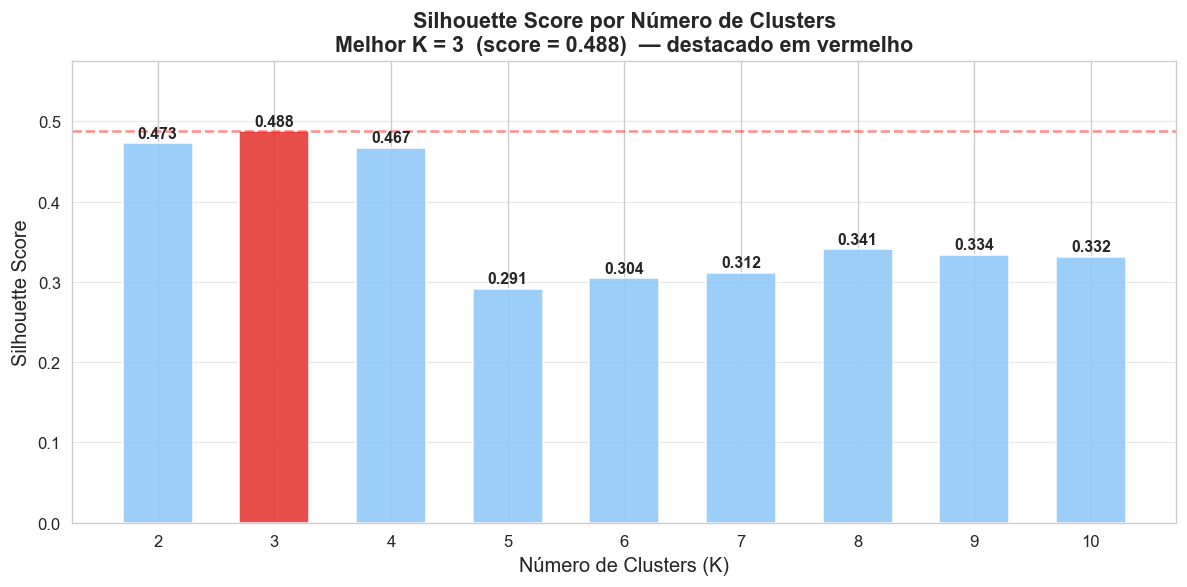


✅ Melhor K pelo Silhouette Score: K = 3  (score = 0.4880)
   Interpretação: -1 (péssimo) → 0 (sobreposto) → +1 (ótimo)


In [11]:
# ─── Silhouette Score ─────────────────────────────────────────────────────────
# sample_size=5000 para agilizar o cálculo sobre 41k registros

silhouette_scores = []

print("Calculando Silhouette Score para K = 2 a 10 (sample_size=5000)...")
print()
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    print(f"  K={k:2d}  Silhouette = {score:.4f}")

best_k_idx = int(np.argmax(silhouette_scores))
best_k     = list(K_range)[best_k_idx]
best_score = silhouette_scores[best_k_idx]

# ── Gráfico ────────────────────────────────────────────────────────────────────
colors_sil = ['#e53935' if k == best_k else '#90CAF9' for k in K_range]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(K_range, silhouette_scores,
              color=colors_sil, alpha=0.9, edgecolor='white', width=0.6)

for bar, score in zip(bars, silhouette_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Silhouette Score por Número de Clusters\n'
             f'Melhor K = {best_k}  (score = {best_score:.3f})  — destacado em vermelho',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(K_range))
ax.set_ylim(0, max(silhouette_scores) * 1.18)
ax.axhline(best_score, color='red', linestyle='--', alpha=0.45, lw=1.5)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Melhor K pelo Silhouette Score: K = {best_k}  (score = {best_score:.4f})")
print("   Interpretação: -1 (péssimo) → 0 (sobreposto) → +1 (ótimo)")

In [12]:
# ─── Ajuste Final do K-Means ──────────────────────────────────────────────────
# K_FINAL é definido pelo Silhouette Score.
# Altere manualmente se o Elbow sugerir outro valor mais interpretável.

K_FINAL = best_k

print(f"🎯 Treinando K-Means com K = {K_FINAL} clusters...")
kmeans        = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\n📊 Distribuição dos Clusters:")
print("-" * 45)
for cid, cnt in df['cluster'].value_counts().sort_index().items():
    pct = cnt / len(df) * 100
    bar = chr(9608) * int(pct / 2)
    print(f"  Cluster {cid}: {cnt:>7,} obs  ({pct:5.1f}%)  {bar}")
print(f"\n  Total  :  {len(df):>7,} obs")
print("\n✅ Coluna 'cluster' adicionada ao DataFrame.")

🎯 Treinando K-Means com K = 3 clusters...

📊 Distribuição dos Clusters:
---------------------------------------------
  Cluster 0:  27,645 obs  ( 67.1%)  █████████████████████████████████
  Cluster 1:  12,005 obs  ( 29.1%)  ██████████████
  Cluster 2:   1,538 obs  (  3.7%)  █

  Total  :   41,188 obs

✅ Coluna 'cluster' adicionada ao DataFrame.


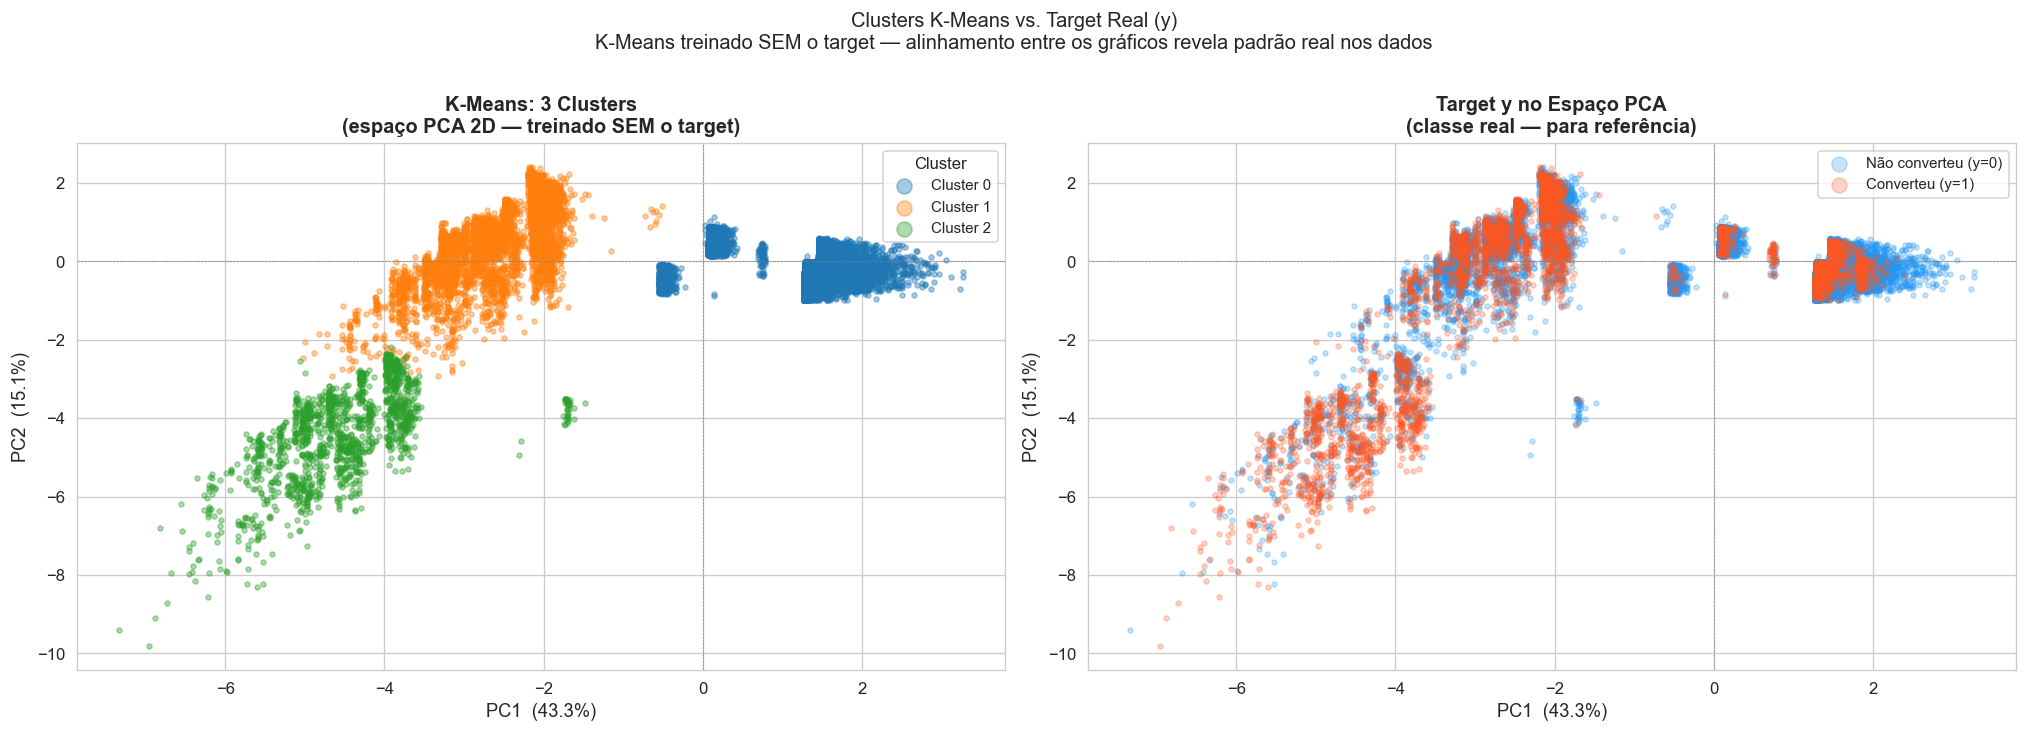

In [13]:
# ─── Visualização: Clusters vs. Target y no Espaço PCA ───────────────────────
palette = sns.color_palette('tab10', n_colors=K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Gráfico 1: colorido por Cluster ───────────────────────────────────────────
ax1 = axes[0]
for k in range(K_FINAL):
    mask = df['cluster'] == k
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[k], label=f'Cluster {k}',
                alpha=0.38, s=9, rasterized=True)

ax1.set_xlabel(f'PC1  ({pc1_var:.1f}%)', fontsize=11)
ax1.set_ylabel(f'PC2  ({pc2_var:.1f}%)', fontsize=11)
ax1.set_title(f'K-Means: {K_FINAL} Clusters\n(espaço PCA 2D — treinado SEM o target)',
              fontsize=12, fontweight='bold')
ax1.legend(title='Cluster', fontsize=9, markerscale=3)
ax1.axhline(0, color='gray', lw=0.4, ls='--')
ax1.axvline(0, color='gray', lw=0.4, ls='--')

# ── Gráfico 2: colorido por y ──────────────────────────────────────────────────
ax2 = axes[1]
for lbl, color, name in zip([0, 1],
                              ['#2196F3', '#FF5722'],
                              ['Não converteu (y=0)', 'Converteu (y=1)']):
    mask = y == lbl
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=color, label=name, alpha=0.25, s=9, rasterized=True)

ax2.set_xlabel(f'PC1  ({pc1_var:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2  ({pc2_var:.1f}%)', fontsize=11)
ax2.set_title('Target y no Espaço PCA\n(classe real — para referência)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, markerscale=3)
ax2.axhline(0, color='gray', lw=0.4, ls='--')
ax2.axvline(0, color='gray', lw=0.4, ls='--')

plt.suptitle('Clusters K-Means vs. Target Real (y)\n'
             'K-Means treinado SEM o target — alinhamento entre os gráficos revela padrão real nos dados',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_kmeans_vs_y.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 6. 📋 Perfil dos Clusters

Identificamos os grupos — agora precisamos **interpretá-los em linguagem de negócio**.

Três etapas:
1. **Estatísticas descritivas** por cluster (médias, medianas, dispersão)
2. **Heatmap de perfil comparativo** — clusters vs. variáveis em Z-Score
3. **Taxa de conversão por cluster** — conexão com o target `y`

> 💡 O K-Means **não** usou o target `y` para criar os grupos. Se um cluster exibir taxa de conversão muito diferente da média geral, isso é evidência de **estrutura real** nos dados correlacionada com o comportamento de compra.

In [14]:
# ─── Estatísticas Descritivas por Cluster ─────────────────────────────────────
print("=" * 70)
print("  📋 ESTATÍSTICAS DESCRITIVAS POR CLUSTER")
print("=" * 70)

for k in sorted(df['cluster'].unique()):
    subset    = df[df['cluster'] == k][numeric_features]
    conv_rate = df[df['cluster'] == k]['y_encoded'].mean() * 100
    n         = len(subset)
    pct       = n / len(df) * 100

    print(f"\n{'─'*70}")
    print(f"  📌 CLUSTER {k}  |  {n:,} obs ({pct:.1f}% do total)  "
          f"|  Taxa de conversão: {conv_rate:.1f}%")
    print(f"{'─'*70}")
    display(subset.describe().round(3))

  📋 ESTATÍSTICAS DESCRITIVAS POR CLUSTER

──────────────────────────────────────────────────────────────────────
  📌 CLUSTER 0  |  27,645 obs (67.1% do total)  |  Taxa de conversão: 4.8%
──────────────────────────────────────────────────────────────────────


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,27645.000,27645.000,27645.0,27645.000,27645.000,27645.000,27645.000,27645.000,27645.000
mean,40.193,2.801,999.0,0.025,1.118,93.844,-39.457,4.818,5213.420
std,9.189,3.153,0.0,0.157,0.493,0.390,2.998,0.277,17.569
min,18.000,1.000,999.0,0.000,-0.100,93.200,-42.700,3.853,5191.000
25%,33.000,1.000,999.0,0.000,1.100,93.444,-42.000,4.857,5191.000
50%,39.000,2.000,999.0,0.000,1.400,93.918,-41.800,4.958,5228.100
75%,47.000,3.000,999.0,0.000,1.400,93.994,-36.400,4.963,5228.100
max,61.000,56.000,999.0,1.000,1.400,94.465,-36.100,5.045,5228.100



──────────────────────────────────────────────────────────────────────
  📌 CLUSTER 1  |  12,005 obs (29.1% do total)  |  Taxa de conversão: 19.4%
──────────────────────────────────────────────────────────────────────


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,12005.000,12005.000,12005.0,12005.000,12005.000,12005.000,12005.000,12005.000,12005.000
mean,39.390,2.125,999.0,0.318,-2.025,92.987,-43.189,1.202,5077.955
std,12.132,1.685,0.0,0.544,0.551,0.449,6.071,0.255,38.812
min,17.000,1.000,999.0,0.000,-3.400,92.201,-50.800,0.634,4963.600
25%,31.000,1.000,999.0,0.000,-1.800,92.893,-46.200,1.059,5076.200
50%,36.000,2.000,999.0,0.000,-1.800,92.893,-46.200,1.281,5099.100
75%,46.000,3.000,999.0,1.000,-1.800,93.075,-40.800,1.344,5099.100
max,98.000,23.000,999.0,3.000,-0.200,94.767,-26.900,3.816,5176.300



──────────────────────────────────────────────────────────────────────
  📌 CLUSTER 2  |  1,538 obs (3.7% do total)  |  Taxa de conversão: 63.1%
──────────────────────────────────────────────────────────────────────


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,1538.000,1538.000,1538.000,1538.000,1538.000,1538.000,1538.000,1538.000,1538.000
mean,41.938,1.828,20.864,1.693,-2.091,93.351,-38.331,0.984,5028.631
std,15.324,1.243,120.618,0.968,0.833,0.784,6.613,0.530,52.212
min,17.000,1.000,0.000,1.000,-3.400,92.201,-50.800,0.634,4963.600
25%,30.000,1.000,3.000,1.000,-2.900,92.649,-42.000,0.718,4991.600
50%,37.000,1.000,6.000,1.000,-1.800,93.200,-38.300,0.879,5017.500
75%,52.000,2.000,7.000,2.000,-1.700,94.055,-31.400,1.041,5076.200
max,98.000,13.000,999.000,7.000,-0.100,94.767,-26.900,4.286,5195.800


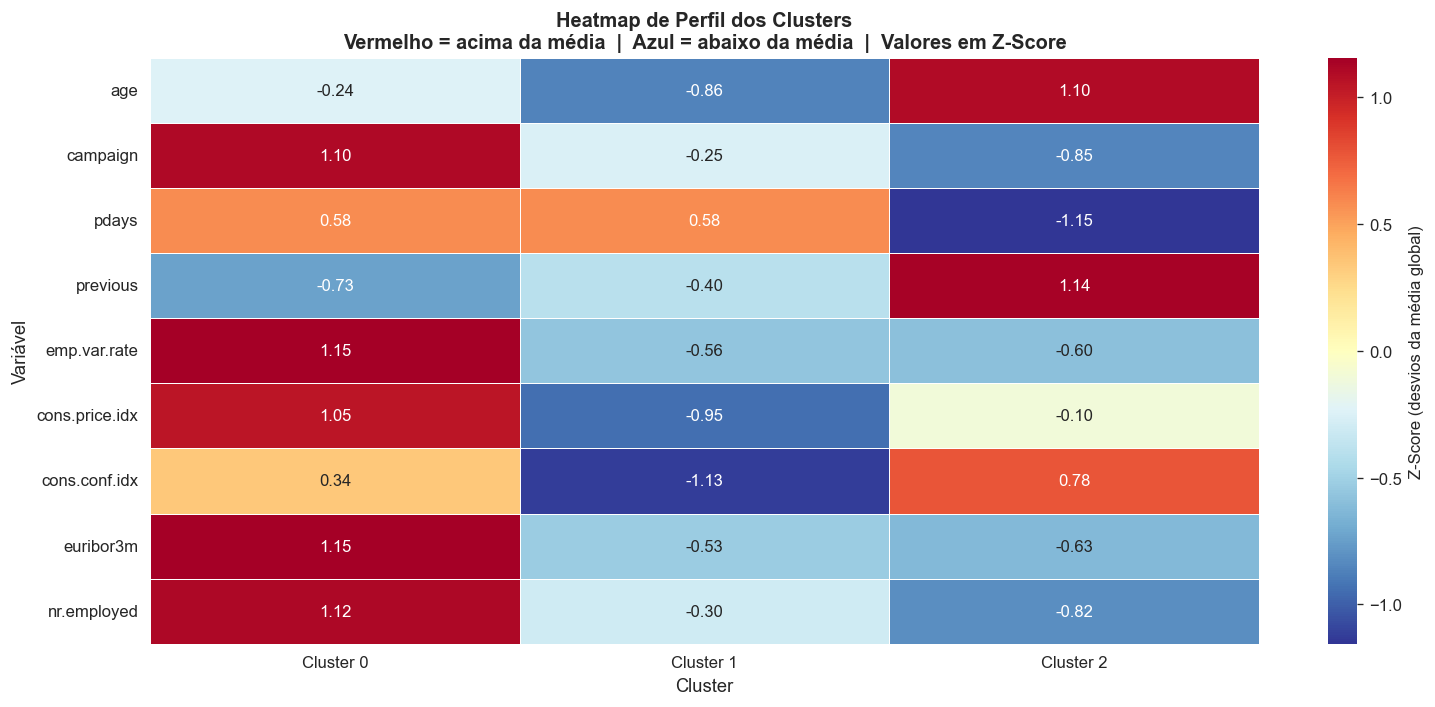


💡 Cada linha = uma variável | Cada coluna = um cluster
   Vermelho = média do cluster acima da média global
   Azul     = média do cluster abaixo da média global


In [15]:
# ─── Heatmap de Perfil dos Clusters ──────────────────────────────────────────
cluster_means     = df.groupby('cluster')[numeric_features].mean()
cluster_means_std = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-9)

fig, ax = plt.subplots(figsize=(13, max(5, K_FINAL + 3)))

sns.heatmap(
    cluster_means_std.T,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0,
    linewidths=0.5, linecolor='white',
    xticklabels=[f'Cluster {k}' for k in cluster_means_std.index],
    yticklabels=numeric_features,
    ax=ax,
    cbar_kws={'label': 'Z-Score (desvios da média global)'}
)

ax.set_title('Heatmap de Perfil dos Clusters\n'
             'Vermelho = acima da média  |  Azul = abaixo da média  |  Valores em Z-Score',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Variável', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Cada linha = uma variável | Cada coluna = um cluster")
print("   Vermelho = média do cluster acima da média global")
print("   Azul     = média do cluster abaixo da média global")

📊 TABELA CRUZADA: Cluster × Resultado da Campanha (y)


y,no,yes,Total
Cluster 0,26310,1335,27645
Cluster 1,9671,2334,12005
Cluster 2,567,971,1538
Total,36548,4640,41188



📈 Taxa de Conversão por Cluster:


,Converteram,Total,Taxa (%)
Cluster 0,1335,27645,4.8
Cluster 1,2334,12005,19.4
Cluster 2,971,1538,63.1


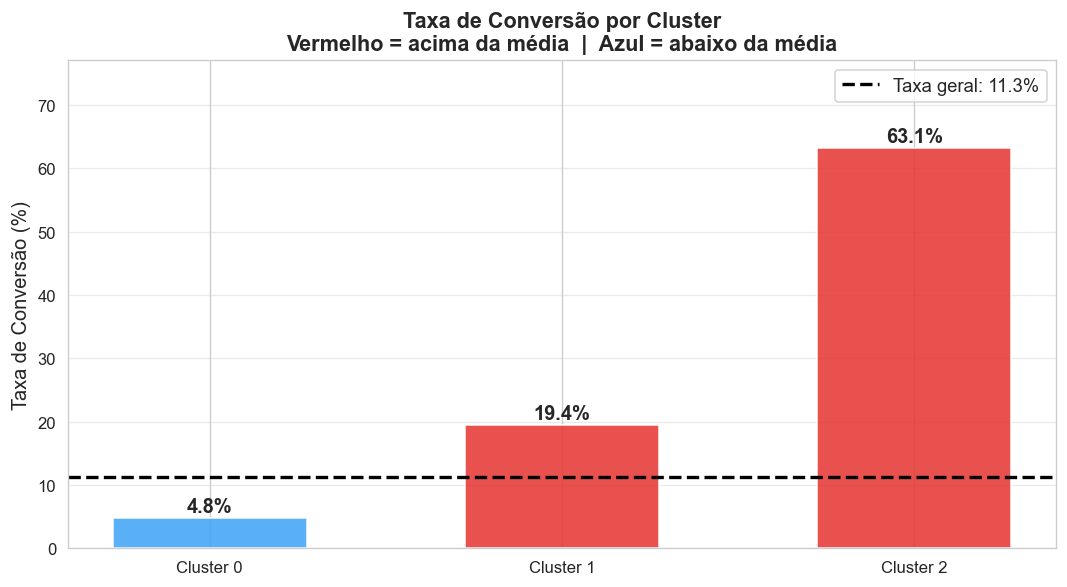

In [16]:
# ─── Tabela Cruzada: Cluster × Target y ──────────────────────────────────────
print("📊 TABELA CRUZADA: Cluster × Resultado da Campanha (y)")
crosstab = pd.crosstab(df['cluster'], df['y'], margins=True, margins_name='Total')
crosstab.index = [f'Cluster {i}' if i != 'Total' else 'Total'
                  for i in crosstab.index]
display(crosstab)

print()
conv_df = (df.groupby('cluster')['y_encoded']
             .agg(Converteram='sum', Total='count')
             .assign(**{'Taxa (%)': lambda x: (x['Converteram'] / x['Total'] * 100).round(1)}))
conv_df.index = [f'Cluster {i}' for i in conv_df.index]
print("📈 Taxa de Conversão por Cluster:")
display(conv_df)

# ── Gráfico de barras ──────────────────────────────────────────────────────────
conv_rates   = df.groupby('cluster')['y_encoded'].mean() * 100
overall_rate = df['y_encoded'].mean() * 100
bar_colors   = ['#e53935' if r > overall_rate else '#42A5F5' for r in conv_rates]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([f'Cluster {k}' for k in conv_rates.index],
              conv_rates, color=bar_colors, alpha=0.88,
              edgecolor='white', width=0.55)

ax.axhline(overall_rate, color='black', linestyle='--', lw=2,
           label=f'Taxa geral: {overall_rate:.1f}%')

for bar, rate in zip(bars, conv_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Taxa de Conversão (%)', fontsize=12)
ax.set_title('Taxa de Conversão por Cluster\n'
             'Vermelho = acima da média  |  Azul = abaixo da média',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, conv_rates.max() * 1.22)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig_conversion_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 7. 🎯 Conclusões

## O que o PCA revelou?

As 9 variáveis numéricas do dataset **não são independentes** — existem padrões de correlação que permitem comprimi-las sem perda significativa de informação. O Scree Plot mostrou a distribuição de variância por componente. O Biplot revelou como as variáveis macroeconômicas (`euribor3m`, `emp.var.rate`, `nr.employed`, `cons.price.idx`) tendem a se mover juntas — capturadas principalmente na PC1 — enquanto variáveis individuais como `age` e `campaign` apontam para direções mais independentes.

---

## O que os Clusters revelaram?

O K-Means — treinado **sem** o target `y` — encontrou grupos com comportamentos distintos. A comparação entre os dois gráficos de scatter é a análise mais importante deste notebook:

- **Clusters alinhados com a separação de `y`** → os dados têm estrutura real correlacionada com conversão
- **Cluster com taxa de conversão acima da média** → segmento prioritário para a campanha
- **Cluster com taxa abaixo da média** → menor retorno esperado por ligação realizada

---

## Limitações desta Abordagem

| Limitação | Impacto |
|---|---|
| K-Means assume clusters esféricos | Grupos com formas irregulares são mal representados |
| Sensível à inicialização | Resultados podem variar — mitigado com `n_init=20` |
| PCA 2D perde informação | Sobreposições no 2D podem não existir nas dimensões superiores |
| `pdays=999` (código especial) | "Nunca contatado" codificado como 999 distorce médias — tratar em produção |

---

## Próximos Passos

1. 🏷️ **Nomear os clusters** usando variáveis categóricas (`job`, `education`, `poutcome`) e contexto de negócio
2. 🔀 **Algoritmos alternativos:** DBSCAN (K não precisa ser definido a priori), Hierarchical Clustering (dendrograma)
3. 🤖 **Pipeline supervisionado:** usar o ID do cluster como feature adicional em Logistic Regression, Random Forest, XGBoost
4. 📊 **Métrica correta para o dataset:** **AUC-PR** em vez de acurácia — com 88,7% da classe majoritária, acurácia é enganosa

---

> 💬 **Mensagem final para os alunos:** PCA e K-Means são ferramentas **exploratórias**. Eles não preveem nada por si só — mas revelam a **estrutura latente** dos dados, transformando-a em hipóteses de negócio testáveis e em features para modelos preditivos mais precisos.